In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# ── Load shapefiles ──────────────────────────────────────
districts = gpd.read_file("D:/Projects/Poverty Predictor Bd/data/raw/shapefiles/gadm41_BGD_2.shp")
divisions  = gpd.read_file("D:/Projects/Poverty Predictor Bd/data/raw/shapefiles/gadm41_BGD_1.shp")

# ── Basic checks ─────────────────────────────────────────
print(f"Districts: {len(districts)}")   # should be 64
print(f"Divisions: {len(divisions)}")   # should be 8
print(f"CRS: {districts.crs}")          # should be EPSG:4326
print(f"\nColumns: {districts.columns.tolist()}")
print(f"\nSample rows:")
print(districts[['GID_2', 'NAME_1', 'NAME_2']].head(10))

# ── Reproject if needed ───────────────────────────────────
if districts.crs.to_epsg() != 4326:
    districts = districts.to_crs("EPSG:4326")
    divisions  = divisions.to_crs("EPSG:4326")
    print("Reprojected to EPSG:4326")

Districts: 64
Divisions: 8
CRS: EPSG:4326

Columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']

Sample rows:
       GID_2      NAME_1         NAME_2
0  BGD.1.1_1     Barisal        Barguna
1  BGD.1.2_1     Barisal        Barisal
2  BGD.1.3_1     Barisal          Bhola
3  BGD.1.4_1     Barisal      Jhalokati
4  BGD.1.5_1     Barisal     Patuakhali
5  BGD.1.6_1     Barisal       Pirojpur
6  BGD.2.1_1  Chittagong      Bandarban
7  BGD.2.2_1  Chittagong  Brahamanbaria
8  BGD.2.3_1  Chittagong       Chandpur
9  BGD.2.4_1  Chittagong     Chittagong


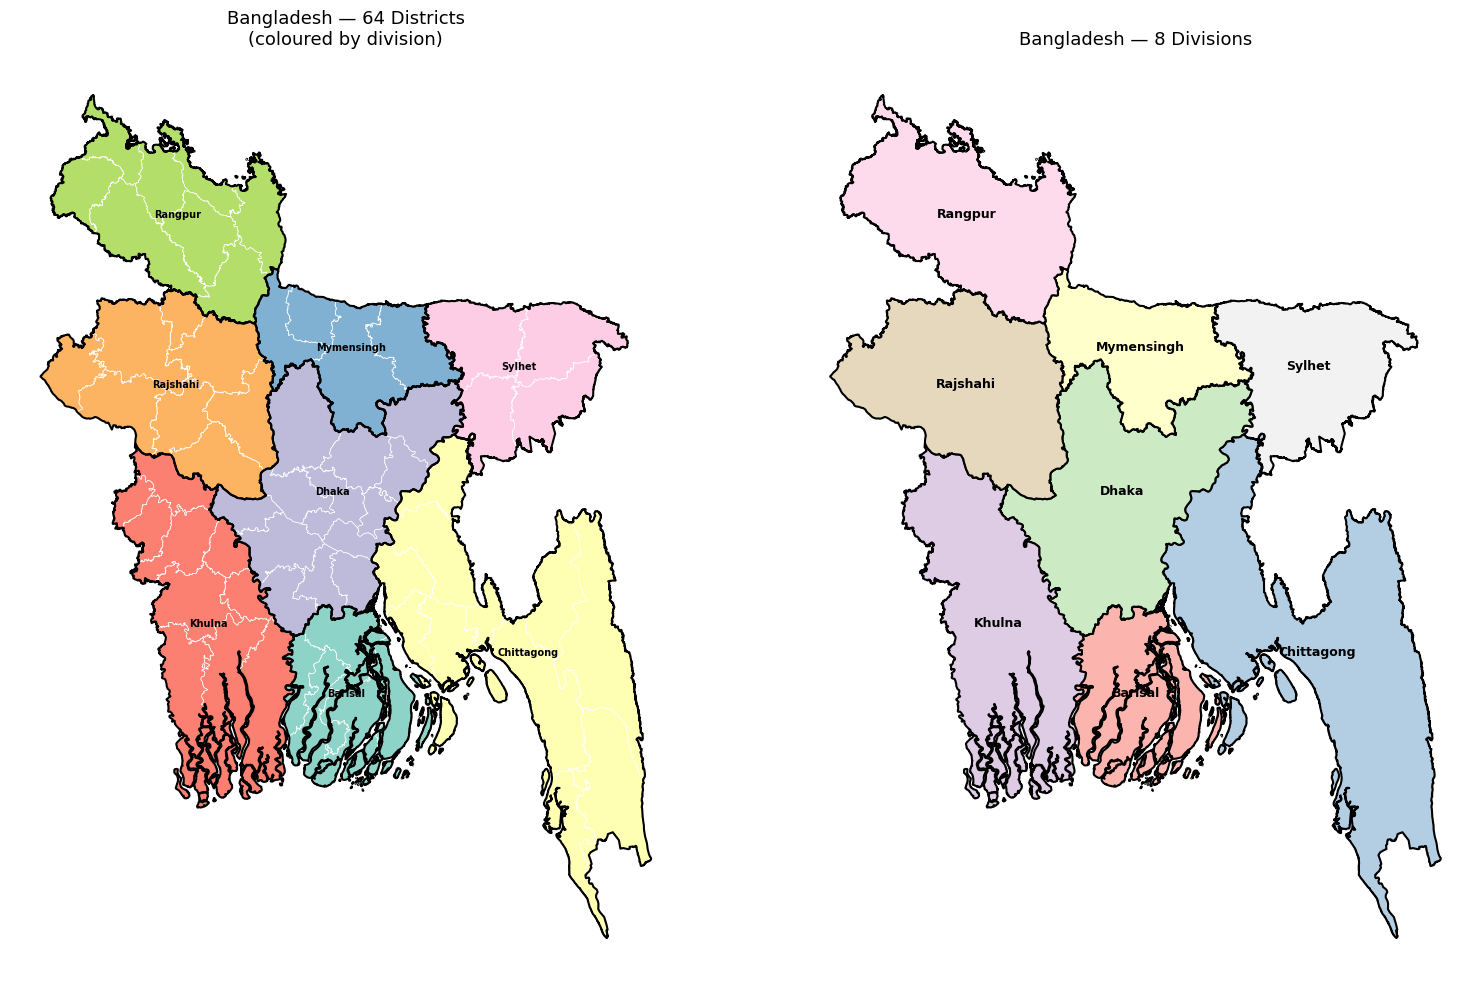

Map saved to outputs/maps/bangladesh_boundaries.png


In [7]:
# ── Plot 1: Districts coloured by division ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: districts shaded by division
division_names = districts['NAME_1'].unique()
colors = plt.cm.Set3.colors
division_color_map = {div: colors[i % len(colors)] 
                      for i, div in enumerate(division_names)}
district_colors = districts['NAME_1'].map(division_color_map)

districts.plot(ax=axes[0], color=district_colors, 
               edgecolor='white', linewidth=0.5)
divisions.plot(ax=axes[0], facecolor='none', 
               edgecolor='black', linewidth=1.5)
axes[0].set_title("Bangladesh — 64 Districts\n(coloured by division)", 
                   fontsize=13)
axes[0].axis('off')

# Add division labels
for _, row in divisions.iterrows():
    centroid = row.geometry.centroid
    axes[0].annotate(row['NAME_1'], xy=(centroid.x, centroid.y),
                     ha='center', fontsize=7, fontweight='bold')

# Right: just division boundaries
divisions.plot(ax=axes[1], cmap='Pastel1', 
               edgecolor='black', linewidth=1.5)
for _, row in divisions.iterrows():
    centroid = row.geometry.centroid
    axes[1].annotate(row['NAME_1'], xy=(centroid.x, centroid.y),
                     ha='center', fontsize=9, fontweight='bold')
axes[1].set_title("Bangladesh — 8 Divisions", fontsize=13)
axes[1].axis('off')

plt.tight_layout()
os.makedirs("outputs/maps", exist_ok=True)
plt.savefig("outputs/maps/bangladesh_boundaries.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Map saved to outputs/maps/bangladesh_boundaries.png")

In [8]:
# ── Verify all 64 district names ─────────────────────────
print("All 64 districts:\n")
for div in sorted(districts['NAME_1'].unique()):
    dist_in_div = districts[districts['NAME_1'] == div]['NAME_2'].tolist()
    print(f"{div} ({len(dist_in_div)} districts):")
    print(f"  {', '.join(sorted(dist_in_div))}\n")

All 64 districts:

Barisal (6 districts):
  Barguna, Barisal, Bhola, Jhalokati, Patuakhali, Pirojpur

Chittagong (11 districts):
  Bandarban, Brahamanbaria, Chandpur, Chittagong, Comilla, Cox'S Bazar, Feni, Khagrachhari, Lakshmipur, Noakhali, Rangamati

Dhaka (13 districts):
  Dhaka, Faridpur, Gazipur, Gopalganj, Kishoreganj, Madaripur, Manikganj, Munshiganj, Narayanganj, Narsingdi, Rajbari, Shariatpur, Tangail

Khulna (10 districts):
  Bagerhat, Chuadanga, Jessore, Jhenaidah, Khulna, Kushtia, Magura, Meherpur, Narail, Satkhira

Mymensingh (4 districts):
  Jamalpur, Mymensingh, Netrakona, Sherpur

Rajshahi (8 districts):
  Bogra, Joypurhat, Naogaon, Natore, Nawabganj, Pabna, Rajshahi, Sirajganj

Rangpur (8 districts):
  Dinajpur, Gaibandha, Kurigram, Lalmonirhat, Nilphamari, Panchagarh, Rangpur, Thakurgaon

Sylhet (4 districts):
  Habiganj, Maulvibazar, Sunamganj, Sylhet



In [10]:
# ── Save cleaned version ──────────────────────────────────
# Keep only the columns you'll need for merging later
districts_clean = districts[['GID_1', 'GID_2', 'NAME_1', 'NAME_2', 'geometry']].copy()
districts_clean = districts_clean.rename(columns={
    'GID_1':  'division_id',
    'GID_2':  'district_id', 
    'NAME_1': 'division_name',
    'NAME_2': 'district_name'
})

districts_clean.to_file(
    "D:/Projects/Poverty Predictor Bd/data/raw/shapefiles/bangladesh_districts_clean.gpkg", 
    driver="GPKG"
)
print(f"Saved clean shapefile: {len(districts_clean)} districts")
print(districts_clean.head())

Saved clean shapefile: 64 districts
  division_id district_id division_name district_name  \
0     BGD.1_1   BGD.1.1_1       Barisal       Barguna   
1     BGD.1_1   BGD.1.2_1       Barisal       Barisal   
2     BGD.1_1   BGD.1.3_1       Barisal         Bhola   
3     BGD.1_1   BGD.1.4_1       Barisal     Jhalokati   
4     BGD.1_1   BGD.1.5_1       Barisal    Patuakhali   

                                            geometry  
0  MULTIPOLYGON (((89.98476 21.9577, 89.98483 21....  
1  MULTIPOLYGON (((90.43166 22.49055, 90.43195 22...  
2  MULTIPOLYGON (((90.81534 21.88569, 90.81492 21...  
3  POLYGON ((90.10083 22.35833, 90.10042 22.35875...  
4  MULTIPOLYGON (((90.45658 21.80762, 90.45665 21...  


In [11]:
# Fix GADM names to match BBS/HIES 2022 standard
gadm_to_bbs = {
    'Barisal':       'Barishal',
    'Chittagong':    'Chattogram',
    'Comilla':       'Cumilla',
    'Jessore':       'Jashore',
    'Bogra':         'Bogura',
    'Nawabganj':     'Chapai Nawabganj',
    'Brahamanbaria': 'Brahmanbaria',
    'Maulvibazar':   'Moulvibazar',
    'Netrakona':     'Netrokona',
    "Cox'S Bazar":   "Cox's Bazar",
}

districts_clean['district_name'] = districts_clean['district_name'].replace(gadm_to_bbs)
districts_clean['division_name'] = districts_clean['division_name'].replace(gadm_to_bbs)

# Verify
print("After standardization:")
for div in sorted(districts_clean['division_name'].unique()):
    dists = districts_clean[districts_clean['division_name'] == div]['district_name'].tolist()
    print(f"  {div}: {', '.join(sorted(dists))}")

After standardization:
  Barishal: Barguna, Barishal, Bhola, Jhalokati, Patuakhali, Pirojpur
  Chattogram: Bandarban, Brahmanbaria, Chandpur, Chattogram, Cox's Bazar, Cumilla, Feni, Khagrachhari, Lakshmipur, Noakhali, Rangamati
  Dhaka: Dhaka, Faridpur, Gazipur, Gopalganj, Kishoreganj, Madaripur, Manikganj, Munshiganj, Narayanganj, Narsingdi, Rajbari, Shariatpur, Tangail
  Khulna: Bagerhat, Chuadanga, Jashore, Jhenaidah, Khulna, Kushtia, Magura, Meherpur, Narail, Satkhira
  Mymensingh: Jamalpur, Mymensingh, Netrokona, Sherpur
  Rajshahi: Bogura, Chapai Nawabganj, Joypurhat, Naogaon, Natore, Pabna, Rajshahi, Sirajganj
  Rangpur: Dinajpur, Gaibandha, Kurigram, Lalmonirhat, Nilphamari, Panchagarh, Rangpur, Thakurgaon
  Sylhet: Habiganj, Moulvibazar, Sunamganj, Sylhet


In [12]:
# Overwrite with corrected names
districts_clean.to_file(
    "D:/Projects/Poverty Predictor Bd/data/raw/shapefiles/bangladesh_districts_clean.gpkg",
    driver="GPKG"
)
print("Saved with standardized names.")

Saved with standardized names.
